### Ev IntelliGrid AI

### EV Charging Stations in Nairobi

*  In this section, we consider the strategic placement of electric vehicle charging infrastructure across the city to support the growing adoption of electric vehicles (EVs). High-traffic areas, residential neighborhoods, malls, supermarkets, offices, and public transport hubs are key considerations. 
* The goal is to place these stations in areas with high vehicle flow and population density, ensuring convenience, accessibility, and efficient service for EV owners. Data-driven analysis using tools like Google Maps API will help identify optimal locations for these stations, contributing to developing a reliable and sustainable EV charging network in Nairobi.

### 1. Import Necessary Libraries

In [4]:
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
from shapely.geometry import LineString, MultiLineString

##### Loading the Model

In [2]:
import pickle
# Update if the path differs
model_path = "kmeans_model.pkl"  
with open(model_path, "rb") as file:
    kmeans_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


### Using Google Maps API

In [3]:
import googlemaps

# Set up API Key
API_KEY = 
gmaps = googlemaps.Client(key=API_KEY)

# Define coordinates
location = (-1.286389, 36.817223)  # Nairobi CBD

# Get the nearest road segment
response = gmaps.nearest_roads([location])
print(response)

[{'location': {'latitude': -1.286388227164223, 'longitude': 36.81722456407105}, 'originalIndex': 0, 'placeId': 'ChIJRQidl9EQLxgRYDdHunTru6o'}]


#### Fetching EV Charging Stations Using Google Maps API

* Fetching EV charging stations using the Google Maps API involves extracting location-based data from key areas of interest, such as malls, petrol stations, public parking, and bus terminals. 
* Leverage  Google’s Places API; gather information on these locations within a specified radius by considering factors like traffic patterns, population density, and access to power from the local grid. 
* This data-driven approach will help identify the most strategic areas for new EV charging stations, ensuring they are conveniently located in high-traffic, underserved, and densely populated regions.

 * Using the Google Maps API, we make a pull request to specifically search for locations with the keyword "EV charging station." We can filter and retrieve relevant results related to existing charging stations by passing this keyword into the API request. 
 * The response returned 19 results, each providing detailed information about the charging stations, including their locations, user ratings, ratings, and precise geographical coordinates. This data helps us identify where EV stations are already established, allowing for better planning and optimization of future station placements.

In [4]:
import requests
import pandas as pd

# Google Maps API Key
API_KEY = API_KEY

# Define Nairobi Coordinates & Search Query
location = "-1.286389,36.817223"  # Nairobi Center
radius = 40000  # Search within 40km
query = "EV charging station"

# Google Places API Request
url = f"https://maps.googleapis.com/maps/api/place/nearbysearch/json?location={location}&radius={radius}&keyword={query}&key={API_KEY}"
response = requests.get(url).json()

# Extract Data
places = []
for place in response.get("results", []):
    places.append({
        "Name": place.get("name"),
        "Latitude": place["geometry"]["location"]["lat"],
        "Longitude": place["geometry"]["location"]["lng"],
        "Address": place.get("vicinity"),
        "Rating": place.get("rating", "N/A"),
        "User Ratings": place.get("user_ratings_total", "N/A"),
        "Place ID": place.get("place_id")
    })

# Convert to DataFrame
ev_google_df = pd.DataFrame(places)

# Display Results
ev_google_df


,Name,Latitude,Longitude,Address,Rating,User Ratings,Place ID
0,BasiGo Charging Station,-1.278185,36.873188,Nairobi,4.2,5,ChIJr-a_lD8VLxgRtWfEgnhCOmA
1,BasiGo Charging Station,-1.283523,36.733083,"PP8M+H6W, Nairobi",0.0,0,ChIJx1_CNAAbLxgRcNbTddKTLpA
2,Electric Vehicle Charging Station,-1.299806,36.794981,"PQ2V+3XH, Ngong Rd, Nairobi",5.0,1,ChIJ2WuIQCwRLxgRRcmgj8RQ4HE
3,Electric Vehicle Charging Station,-1.329837,36.714577,"MPC7+3R8, Langata Rd, Nairobi",4.0,6,ChIJWb6CLIwbLxgRUIGF10_Ep_c
4,EVChaja Charging Station,-1.210779,36.794627,"QQQV+MVJ, Limuru Rd, Nairobi",5.0,1,ChIJ_UZcdPs9LxgRny7PVgC9cL0
5,Roam Hub - Lusaka,-1.301325,36.832909,"Total Energies, Lusaka Rd, Nairobi",4.3,17,ChIJTwVS7gARLxgRuAE_0KQMvs8
6,Roam Hub - Wayaki Way,-1.258721,36.781323,"Waiyaki Wy, Nairobi",5.0,1,ChIJTz9iImUZLxgR_zJglYTMuJY
7,Ecotrify,-1.289189,36.793277,"Mpuuga Gardens, Hurlingham Court, Rose Ave, Na...",0.0,0,ChIJIduyaMgRLxgRmcLgXYPwzvM
8,SupaChaja Charging Station,-1.186758,36.997345,Ruiru,4.0,2,ChIJXy8RCoVBLxgRRKUmWyPEFos
9,Roam Hub - Quickmart Roysambu,-1.215213,36.891751,"Quickmart, Nairobi",5.0,1,ChIJ56_AwMo_LxgRE0bh-eVUohs


### Fetching Traffic Data for EV Stations
* Make pull request to retrieve traffic data for specific locations relevant to EV stations using the Google Maps API. The API provides real-time information on road congestion, traffic volume, and average travel times by passing coordinates and querying traffic patterns. This data helps assess the accessibility of EV charging stations, ensuring they are placed in high-traffic areas with significant vehicle flow, thereby optimizing their visibility and usage.
* However, in our case, the pull request could not return real-time traffic data as expected, which may require further investigation or using other primary methods to obtain traffic data.


In [8]:
import time

# Get Traffic Data for Each Station
traffic_data = []

for _, row in ev_google_df.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    
    traffic_url = f"https://maps.googleapis.com/maps/api/distancematrix/json?origins={lat},{lon}&destinations={lat},{lon}&departure_time=now&key={API_KEY}"
    response = requests.get(traffic_url).json()
    
    # Check if "rows" exist and contains elements
    if "rows" in response and response["rows"]:
        if "elements" in response["rows"][0] and response["rows"][0]["elements"]:
            element = response["rows"][0]["elements"][0]
            traffic_status = element.get("status", "No Data")
            duration_traffic = element.get("duration_in_traffic", {}).get("text", "N/A")
        else:
            traffic_status = "No Data"
            duration_traffic = "N/A"
    else:
        traffic_status = "No Data"
        duration_traffic = "N/A"

    traffic_data.append({
        "Name": row["Name"],
        "Traffic_Status": traffic_status,
        "Duration_Traffic": duration_traffic
    })
    
    # Avoid hitting API rate limits
    time.sleep(1)

# Convert to DataFrame
traffic_df = pd.DataFrame(traffic_data)

# Display Traffic Data
traffic_df


,Name,Traffic_Status,Duration_Traffic
0,BasiGo Charging Station,No Data,N/A
1,Electric Vehicle Charging Station,No Data,N/A
2,Electric Vehicle Charging Station,No Data,N/A
3,EVChaja Charging Station,No Data,N/A
4,BasiGo Charging Station,No Data,N/A
5,Roam Hub - Wayaki Way,No Data,N/A
6,Ecotrify,No Data,N/A
7,SupaChaja Charging Station,No Data,N/A
8,BasiGo Depot - Embakasi,No Data,N/A
9,Roam Hub - Quickmart Roysambu,No Data,N/A


In [5]:
ev_google_df2 = ev_google_df[['Latitude','Longitude', 'Name']]
ev_google_df1 = ev_google_df2.copy()
ev_google_df2.head()

,Latitude,Longitude,Name
0,-1.278185,36.873188,BasiGo Charging Station
1,-1.283523,36.733083,BasiGo Charging Station
2,-1.299806,36.794981,Electric Vehicle Charging Station
3,-1.329837,36.714577,Electric Vehicle Charging Station
4,-1.210779,36.794627,EVChaja Charging Station


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Columns to scale
columns_to_scale = ['Latitude', 'Longitude']

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scale the specified columns
ev_google_df2[columns_to_scale] = scaler.fit_transform(ev_google_df2[columns_to_scale])

# Columns that were not scaled (you can adjust this list as necessary)
columns_not_to_scale = [col for col in ev_google_df2.columns if col not in columns_to_scale]

# Concatenate the scaled columns with the non-scaled columns
ev_google_df2_scaled = ev_google_df2[columns_not_to_scale + columns_to_scale]

# Display the updated DataFrame
ev_google_df2_scaled.head()


<ipython-input-6-b2a9ec4ac44a>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_google_df2[columns_to_scale] = scaler.fit_transform(ev_google_df2[columns_to_scale])
C:\Users\user\anaconda3\envs\learn-env\lib\site-packages\pandas\core\indexing.py:1736: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value[:, i].tolist())


,Name,Latitude,Longitude
0,BasiGo Charging Station,0.179834,0.501878
1,BasiGo Charging Station,0.161247,0.150520
2,Electric Vehicle Charging Station,0.104557,0.305750
3,Electric Vehicle Charging Station,0.000000,0.104112
4,EVChaja Charging Station,0.414514,0.304862


In [7]:
# Load the new dataset
new_data = ev_google_df2_scaled

# Convert column names to lowercase to avoid case-sensitivity issues
new_data.columns = new_data.columns.str.lower()

# Check if required columns exist
required_features = ['latitude', 'longitude']
missing_features = [col for col in required_features if col not in new_data.columns]

if missing_features:
    raise ValueError(f"Dataset is missing required columns: {missing_features}")

# Predict clusters using the loaded K-Means model
predictions = pd.DataFrame(kmeans_model.predict(new_data[required_features]), columns=['cluster'])

# Concatenate the original dataset with the predictions
ev_google_df1['cluster'] = predictions

# Display first few rows of the dataset with clusters
print("\nClustered Dataset Preview:")
ev_google_df1.head()


Clustered Dataset Preview:


,Latitude,Longitude,Name,cluster
0,-1.278185,36.873188,BasiGo Charging Station,4
1,-1.283523,36.733083,BasiGo Charging Station,4
2,-1.299806,36.794981,Electric Vehicle Charging Station,4
3,-1.329837,36.714577,Electric Vehicle Charging Station,4
4,-1.210779,36.794627,EVChaja Charging Station,3


#### Clustering the Existing Ev charging stations

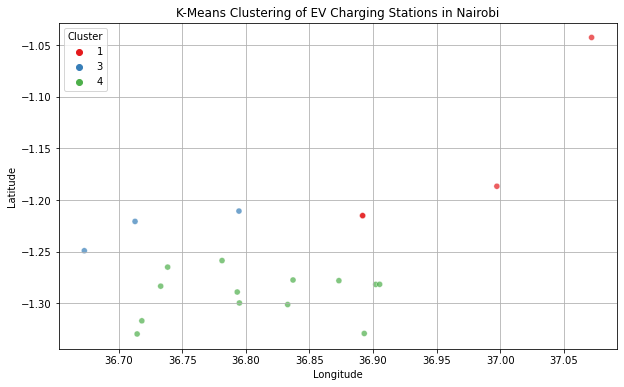

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

# Assuming new_data is the DataFrame containing the necessary columns
# Load your data
# new_data = pd.read_csv("your_file.csv")  # Uncomment if you load the data from a file

# Scatter Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ev_google_df1['Longitude'], y= ev_google_df1['Latitude'], hue= ev_google_df1['cluster'], palette="Set1", alpha=0.7)
plt.title("K-Means Clustering of EV Charging Stations in Nairobi")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

# Interactive Map with Folium
# Initialize the map centered around Nairobi
nairobi_map = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Add marker clusters
marker_cluster = MarkerCluster().add_to(nairobi_map)

# Add charging stations to the map
for _, row in ev_google_df1.iterrows():
    # Determine color based on predicted cluster
    color = "blue" if row['cluster'] == 0 else "red"
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Station: {row['Name']} (Cluster {row['cluster']})",
#         icon=folium.Icon(color=color),
        icon=folium.Icon(color="orange", icon="bolt", prefix="fa")
    ).add_to(marker_cluster)

# Show map
nairobi_map


* The model struggled to make structured predictions due to insufficient features like live traffic data, power grid availability, and vehicle population density. The model couldn’t generate accurate insights for optimal EV charging station placement with minimal data available. To improve, we can start by plotting the existing charging stations to identify gaps and underserved areas. 
* Focus on points of interest in Nairobi county, like shopping malls, petrol stations, office buildings, and public transport hubs are high-traffic locations. This will guide the placement of new stations in high-traffic locations.
- Extracting additional data, such as the locations of shopping malls and other key establishments, will help refine our predictions. These locations typically have high foot traffic and long dwell times, making them ideal for EV charging stations. - Without real-time traffic or power grid data, we can use these points of interest to predict areas where new stations will be most needed, enhancing the coverage and accessibility of the EV infrastructure in Nairobi.

### 5 Strategic EV Placement Areas and 10 Areas that they can be placed because they are underserved

For the BasiGo data set, the below code plots the present Ev charging stations points on the route

In [13]:
import googlemaps
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
import numpy as np
from shapely.geometry import MultiLineString
from sklearn.cluster import KMeans
import random

# Replace with your Google API Key
API_KEY = API_KEY
gmaps = googlemaps.Client(key=API_KEY)

# ================================
# Fetch EV Charging Stations from Google Maps
# ================================
def get_charging_stations(location=(-1.286389, 36.817223), radius=30000):
    places_result = gmaps.places_nearby(
        location=location,
        radius=radius,
        keyword="EV charging station",
        type="point_of_interest"
    )
    
    stations = []
    for place in places_result.get("results", []):
        stations.append({
            "Station": place["name"],
            "Latitude": place["geometry"]["location"]["lat"],
            "Longitude": place["geometry"]["location"]["lng"],
            "Rating": place.get("rating", "N/A"),
            "Address": place.get("vicinity", "N/A")
        })
    
    return pd.DataFrame(stations)

charging_df = get_charging_stations()

# Distinguish Providers and Assign Colors
provider_colors = {}
unique_providers = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown").unique()
colors = ["blue", "green", "red", "purple", "orange", "darkblue", "darkred", "cadetblue", "lightblue", "darkgreen"]
random.shuffle(colors)
for i, provider in enumerate(unique_providers):
    provider_colors[provider] = colors[i % len(colors)]

charging_df["Provider"] = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown")

# ================================
# Load BasiGo Bus Route Data
# ================================
routes_data = {
    "Route": [
        "CBD - Allsops - JKIA", "CBD - Buruburu - Dandora", "CBD - Jogoo Road - Buruburu",
        "CBD - Jacaranda - Nyayo", "CBD - Kikuyu - Kitengela", "Utawala - Upperhill - Kiambu",
        "CBD - Kasarani - Mwiki", "CBD - Thika Road - Ruiru", "CBD - Lang'ata - Ongata Rongai",
        "CBD - South C - Mombasa Road", "CBD - Westlands - Lavington", "CBD - Karen - Ngong"
    ],
    "Operator": [
        "Citi Hoppa", "East Shuttle", "OMA Services", "Embassava", "Super Metro", "Metro Trans",
        "KBS", "Joy Shuttle", "City Hoppa", "Express Connections", "Metro Shuttle", "Super Metro"
    ]
}

routes_df = pd.DataFrame(routes_data)

# ================================
# Generate BasiGo Bus Routes
# ================================
G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
endpoints = [
    ((-1.2864, 36.8172), (-1.3192, 36.9275)), ((-1.2864, 36.8172), (-1.2791, 36.8993)),
    ((-1.2864, 36.8172), (-1.2898, 36.8572)), ((-1.2864, 36.8172), (-1.3070, 36.8521)),
    ((-1.2864, 36.8172), (-1.2471, 36.6673)), ((-1.2864, 36.8172), (-1.2245, 36.8365)),
    ((-1.2864, 36.8172), (-1.2173, 36.8985)), ((-1.2864, 36.8172), (-1.1435, 37.0132)),
    ((-1.2864, 36.8172), (-1.3958, 36.6963)), ((-1.2864, 36.8172), (-1.3309, 36.8608)),
    ((-1.2864, 36.8172), (-1.2836, 36.7834)), ((-1.2864, 36.8172), (-1.3125, 36.6749))
]

routes_lines = []
for start, end in endpoints:
    orig = ox.distance.nearest_nodes(G, start[1], start[0])
    dest = ox.distance.nearest_nodes(G, end[1], end[0])
    route = ox.shortest_path(G, orig, dest, weight='length')
    edges = ox.graph_to_gdfs(G.subgraph(route), nodes=False)
    route_geom = MultiLineString(edges.geometry.values)
    routes_lines.append(route_geom)

routes_gdf = gpd.GeoDataFrame({'Route': routes_data['Route'], 'Operator': routes_data['Operator'], 'geometry': routes_lines}, crs="EPSG:4326")

# ================================
# Suggest New Charging Locations (Away from Centroids)
# ================================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(charging_df[["Latitude", "Longitude"]])
new_station_locations = kmeans.cluster_centers_ + (np.random.rand(*kmeans.cluster_centers_.shape) - 0.5) * 0.05

# ================================
# Generate Folium Map
# ================================
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Add Charging Stations
for _, row in charging_df.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        popup=f"{row['Station']} ({row['Provider']})",
        tooltip=row["Station"],
        icon=folium.Icon(color=provider_colors.get(row["Provider"], "gray"), icon="bolt", prefix="fa")
    ).add_to(m)

# Add Suggested Charging Stations
for lat, lon in new_station_locations:
    folium.Marker(
        [lat, lon],
        popup="Suggested Charging Station",
        icon=folium.Icon(color="orange", icon="bolt", prefix="fa")
    ).add_to(m)

# Add BasiGo Bus Routes
for _, row in routes_gdf.iterrows():
    for line in row['geometry'].geoms:
        folium.PolyLine([(lat, lon) for lon, lat in line.coords], color="red", weight=2.5, tooltip=f"{row['Route']} ({row['Operator']})").add_to(m)

# Save Results
charging_df.to_csv("nairobi_charging_stations.csv", index=False)

m


1. Yellow - the suggested charging stations are purely based on underserved areas and existing Ev charging stations infrastructure.
2. Blue - BasiGo charging stations.
3. Green - EV chaja charging stations.
4. yellow - Ampersand charging stations.
5. Brown - Electric Vehicle charging station.

* To effectively map new EV charging stations in Nairobi, a strategic approach should focus on key points of interest (POIs) and underserved areas. High-traffic POIs such as shopping malls, petrol stations, office buildings, and public transport hubs are ideal locations for charging stations, given their frequent traffic. These locations typically offer high visibility and accessibility, making them well-suited for EV infrastructure.
* Below, we make API pull requests to Google to obtain a list of POIs in Nairobi. This data will be used to map potential EV charging stations, focusing on underserved and  high demand areas.

#### Suggested Charging Stations Near Points of Interest and Underserved Areas

In [14]:
import googlemaps
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
import numpy as np
from shapely.geometry import MultiLineString
from sklearn.cluster import KMeans, DBSCAN
import random

# Replace with your Google API Key
API_KEY = API_KEY
gmaps = googlemaps.Client(key=API_KEY)


# Fetch EV Charging Stations from Google Maps

def get_charging_stations(location=(-1.286389, 36.817223), radius=30000):
    places_result = gmaps.places_nearby(
        location=location,
        radius=radius,
        keyword="EV charging station",
        type="point_of_interest"
    )
    
    stations = []
    for place in places_result.get("results", []):
        stations.append({
            "Station": place["name"],
            "Latitude": place["geometry"]["location"]["lat"],
            "Longitude": place["geometry"]["location"]["lng"],
            "Rating": place.get("rating", "N/A"),
            "Address": place.get("vicinity", "N/A")
        })
    
    return pd.DataFrame(stations)

charging_df = get_charging_stations()

# ================================
# Fetch High-Traffic POIs (Including Public Parking, Petrol Stations, and Bus Terminals)
# ================================
def get_pois(location=(-1.286389, 36.817223), radius=30000):
    search_keywords = ["mall", "petrol station", "public parking", "bus terminal"]
    pois = []
    for keyword in search_keywords:
        places_result = gmaps.places_nearby(
            location=location,
            radius=radius,
            keyword=keyword,
            type="point_of_interest"
        )
        for place in places_result.get("results", []):
            pois.append({
                "Name": place["name"],
                "Type": keyword,
                "Latitude": place["geometry"]["location"]["lat"],
                "Longitude": place["geometry"]["location"]["lng"],
                "Rating": place.get("rating", "N/A"),
                "Address": place.get("vicinity", "N/A")
            })
    return pd.DataFrame(pois)

pois_df = get_pois()

# Distinguish Providers and Assign Unique Colors
unique_providers = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown").unique()
color_palette = ["blue", "green", "red", "purple", "orange", "darkblue", "darkred", "cadetblue", "lightblue", "darkgreen"]
random.shuffle(color_palette)
provider_colors = {provider: color_palette[i % len(color_palette)] for i, provider in enumerate(unique_providers)}
charging_df["Provider"] = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown")

# ================================
# Identify Underserved Areas & Place New Stations Along Roads/Highways
# ================================
charging_locations = charging_df[["Latitude", "Longitude"]].values
poi_locations = pois_df[["Latitude", "Longitude"]].values

# Use K-Means clustering to place new stations near POIs
num_new_stations = min(10, len(poi_locations))  # Limit the number of suggested stations
if num_new_stations > 0:
    kmeans = KMeans(n_clusters=num_new_stations, random_state=42, n_init=10)
    kmeans.fit(poi_locations)
    new_station_locations = kmeans.cluster_centers_
    
    # Adjust station locations to be along roads/highways using OSMNx
    G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
    adjusted_station_locations = []
    for lat, lon in new_station_locations:
        nearest_node = ox.distance.nearest_nodes(G, lon, lat)
        nearest_point = (G.nodes[nearest_node]['y'], G.nodes[nearest_node]['x'])
        adjusted_station_locations.append(nearest_point)
else:
    adjusted_station_locations = []

# ================================
# Generate Folium Map
# ================================
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Add Charging Stations with Provider Colors
for _, row in charging_df.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        popup=f"{row['Station']} ({row['Provider']})",
        tooltip=row["Station"],
        icon=folium.Icon(color=provider_colors.get(row["Provider"], "gray"), icon="bolt", prefix="fa")
    ).add_to(m)

# Add POIs
poi_colors = {"mall": "blue", "petrol station": "red", "public parking": "darkpurple", "bus terminal": "black"}
for _, row in pois_df.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        popup=f"{row['Name']} ({row['Type']})", 
        tooltip=row["Name"],
        icon=folium.Icon(color=poi_colors.get(row["Type"], "gray"), icon="info-sign")
    ).add_to(m)

# Add Suggested Charging Stations with Labels (Placed Along Roads/Highways)
for i, (lat, lon) in enumerate(adjusted_station_locations):
    folium.Marker(
        [lat, lon],
        popup=f"Suggested Charging Station {i+1} (Near High-Demand POI & Along Highway)",
        tooltip=f"New Charging Site {i+1}",
        icon=folium.Icon(color="orange", icon="bolt", prefix="fa")
    ).add_to(m)

# Save Results
charging_df.to_csv("nairobi_charging_stations.csv", index=False)
pois_df.to_csv("nairobi_pois_data.csv", index=False)

m


### Saving the Trained Model

In [17]:
import joblib

# Save the trained K-Means model
joblib.dump(kmeans, "kmeans_ev_model.pkl")

print("Model saved successfully as 'kmeans_ev_model.pkl'.")

Model saved successfully as 'kmeans_ev_model.pkl'.


### Loading the Model

In [16]:
# Load the trained K-Means model
kmeans_loaded = joblib.load("kmeans_ev_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


#### Model Deployment
* The model was successfully deployed using FastAPI with Uvicorn.

### Conclusions
- The model was able to successfully predict ten charging stations based on both points of interest and underserved areas.
- We successfully achieved our objective by developing an AI-powered platform that accurately identifies optimal EV charging station locations through the integration of real-time usage data, geospatial analysis, and traffic patterns.
- Despite facing constraints in obtaining reliable traffic data, vehicle population density, and KPLC power grid information, the model effectively addresses underserved areas and aligns with regional infrastructure needs, ensuring scalability and sustainability. This platform provides an efficient, data-driven solution for expanding EV charging infrastructure.

#### Recommendations

1. Incorporate Underserved Residential Areas into the Model: Enhance the mapping model by including highly modern populated residential neighborhoods in the suburbs of Nairobi. This will ensure the model identifies regions with limited charging infrastructure, allowing for optimized placement of new stations in underserved areas.
2. Optimize Station Placement Based on Traffic and Accessibility Data: Integrate real-time traffic patterns and road accessibility into the model. Prioritize high-traffic roads, like the Waiyaki Way and Mombasa Road, to ensure the model suggests charging stations at easily accessible and strategic points. This approach will improve station coverage and reduce charging time for users by placing stations along major commuter routes.
3. Factor in Power Grid Access and Sustainable Energy Solutions: Refine the model by integrating data on power grid access and incorporating sustainable energy options, like solar charging stations. This will enable the model to recommend locations that meet demand and are supported by reliable and sustainable energy sources, ensuring the charging network's efficient operation and long-term viability.

#### Next Steps

* More data Integration: The first step is to gather and integrate a range of data, including real-time EV usage patterns, geospatial data, traffic flow, access to the power grid, and sustainability options like solar energy potential. With this data, we will fine-tune machine learning algorithms and geospatial analysis tools to make the most accurate predictions for where EV charging stations should be located.

* Deployment to a cloud platform like AWS, google Cloud Platform (GCP)or Microsoft Azure

* Testing and  Evaluation: Implementing the platform in a select region like Nairobi will test the model's real-world effectiveness. Based on the model's recommendations, charging stations will be deployed, and we will collect real-time data on usage, traffic, and sustainability to evaluate the platform's performance.

* Stakeholder Collaboration: Ensure the platform aligns with regional policies and infrastructural requirements. Collaborate with energy providers,  local authorities, and other stakeholders. 